In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy
from astropy.io import fits
import time

# Euclid imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.observables.CometEFT_spectro import CometEFT_SpectroPower
from cloelib.observables.CometVDG_spectro import CometVDG_SpectroPower
#from cloelib.observables.PBJ_spectro import PBJSpectroPower

from cloelib.summary_statistics.legendre_multipoles import LegendreMultipoles

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

Warning! "libgrid.so" not found, bispectrum binning options will not be available.


/Users/pezzotta/opt/anaconda3/envs/cloelite/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator GaussianProcessRegressor from version 1.4.1.post1 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [2]:
H0 = 67.7
Omega_cdm0 = 0.27
Omega_b0 = 0.049
Omega_k0 = 0.0
w0 = -1.0
wa = 0.0
ns = 0.96
As = 2.1e-9
gamma_MG = 0.545
mnu = 0.0

background_fiducial = CAMBBackground(
    H0=H0, Omega_cdm0=Omega_cdm0, Omega_b0=Omega_b0, Omega_k0=Omega_k0,
    w0=w0, wa=wa, ns=ns, As=As, gamma_MG=gamma_MG, mnu=mnu
)

Omega_cdm0 = 0.28
H0 = 70.0

background = CAMBBackground(
    H0=H0, Omega_cdm0=Omega_cdm0, Omega_b0=Omega_b0, Omega_k0=Omega_k0,
    w0=w0, wa=wa, ns=ns, As=As, gamma_MG=gamma_MG, mnu=mnu
)

In [ ]:
# Always needed by PBJ: an object that follows the Perturbations protocol
# Quantities needed are the linear power spectrum at z=0 ans the growth functions at requested redshift
zs = [1.]
linear_perturbations = CAMBLinearPerturbations(background, zs)

In [ ]:
RSD_parameters = {
 'b1': 1.412, 'b2': 0.695, 'bG2': -0.156, 'bGam3': 0.323,
 'c0': 30.948, 'c2': 46.233, 'c4': 10.057, 'cnlo': 0.0
}

In [ ]:
comet_pk2 = CometEFT_SpectroPower(background=background, RSD_parameters=RSD_parameters, redshift=1.0)                            

In [ ]:
# PBJ
# Note I'm changing the counterterms to match, given the different parameterisation
RSD_parameters_pbj = {
 'b1': 1.412, 'b2': 0.695, 'bG2': -0.156, 'bG3': 0.323,
 'c0': 11.602875000000001, 'c2': 35.82984756123215, 'c4': 56.439110254601786, 'cko': 0.0
}
pbj_pk2 = PBJSpectroPower(linear_perturbations=linear_perturbations, nuisance_parameters=RSD_parameters_pbj)

In [ ]:
noise_syst_parameters = {
 'NP0': 1.056, 'NP20': 0.0, 'NP22': 0.0,
 'fout': 0.0, 'sigmaz': 0.0
}

In [ ]:
# Here to switch from comet to pbj I just change the input of LegendreMultipoles from comet_pk2 to pbj_pk2
mps_spectro_comet = LegendreMultipoles(comet_pk2, background_fiducial, noise_syst_parameters, nbar=1e-4)
mps_spectro_pbj = LegendreMultipoles(pbj_pk2, background_fiducial, noise_syst_parameters, nbar=1e-4)

In [ ]:
k = np.logspace(-3, np.log10(0.3), 101)
mps = mps_spectro_comet.power_multipoles(k=k, ells=[0,2,4])
mps_pbj = mps_spectro_pbj.power_multipoles(k=k, ells=[0,2,4])

In [ ]:
# Comet vs PBJ
plt.loglog(k, mps['ell0'])
plt.loglog(k, mps_pbj['ell0'], ls='--')
plt.loglog(k, mps['ell2'])
plt.loglog(k, mps_pbj['ell2'], ls='--')
plt.loglog(k, mps['ell4'])
plt.loglog(k, mps_pbj['ell4'], ls='--')

In [ ]:
plt.semilogx(k, 100*(mps['ell0']/mps_pbj['ell0']-1), label=r'$P_0$')
plt.semilogx(k, 100*(mps['ell2']/mps_pbj['ell2']-1), label=r'$P_2$')
plt.semilogx(k, 100*(mps['ell4']/mps_pbj['ell4']-1), label=r'$P_4$')
plt.ylabel(r'\% difference')
plt.xlabel(r'$k$')
plt.legend()


In [ ]:
# COMET without AP
mps_noAP = mps_spectro_comet.power_multipoles(k=k, ells=[0,2,4], use_AP=False)

In [ ]:
# Impact of AP distortions
plt.loglog(k, mps['ell0'], label="with AP distortions")
plt.loglog(k, mps_noAP['ell0'], ls='--', label="no AP distortions")
plt.loglog(k, mps['ell2'])
plt.loglog(k, mps_noAP['ell2'], ls='--')
plt.loglog(k, mps['ell4'])
plt.loglog(k, mps_noAP['ell4'], ls='--')
plt.xlabel(r'$k$')
plt.ylabel(r'$P_\ell(k)$')
plt.legend()


In [ ]:
RSD_parameters['b1'] = 2.0
RSD_parameters_pbj['b1'] = 2.0
noise_syst_parameters['fout'] = 0.2
noise_syst_parameters['sigmaz'] = 0.002

comet_pk2 = CometEFT_SpectroPower(background=background, RSD_parameters=RSD_parameters, redshift=1.0) 
pbj_pk2 = PBJSpectroPower(linear_perturbations=linear_perturbations, nuisance_parameters=RSD_parameters_pbj) 

mps_spectro = LegendreMultipoles(comet_pk2, background_fiducial, noise_syst_parameters, nbar=1e-4)
mps_spectro_pbj = LegendreMultipoles(pbj_pk2, background_fiducial, noise_syst_parameters, nbar=1e-4)

mps1 = mps_spectro.power_multipoles(k=k, ells=[0,2,4])
mps1_pbj = mps_spectro.power_multipoles(k=k, ells=[0,2,4])

In [ ]:
# Impact of RSD parameters
plt.loglog(k, mps['ell0'], label="COMET, original")
plt.loglog(k, mps1['ell0'], label="COMET, new rsd params")
plt.loglog(k, mps['ell2'])
plt.loglog(k, mps1['ell2'])
plt.loglog(k, mps['ell4'])
plt.loglog(k, mps1['ell4'])
plt.loglog(k, mps1_pbj['ell0'], ':', label="PBJ, new rsd params")
plt.loglog(k, mps1_pbj['ell2'], ':')
plt.loglog(k, mps1_pbj['ell4'], ':')
plt.legend()

In [ ]:
background1 = CAMBBackground(H0=75.0, 
                             Omega_cdm0=0.25, 
                             Omega_b0=0.049, 
                             w0=-1.5, 
                             wa=0, 
                             Omega_k0 = 0.0, 
                             ns = 0.7, 
                             As = 3.1e-9,
                             gamma_MG = 0.545,
                             mnu=0.0)

In [ ]:
comet_pk2 = CometEFT_SpectroPower(background=background1, RSD_parameters=RSD_parameters, redshift=1.0) 

mps_spectro = LegendreMultipoles(comet_pk2, background_fiducial, noise_syst_parameters, nbar=1e-4)

mps2 = mps_spectro.power_multipoles(k=k, ells=[0,2,4])

In [ ]:
# PBJ with different cosmology (needs to instantiate a new CAMBLinearPerturbations object
zs = [1.]
linear_perturbations1 = CAMBLinearPerturbations(background1, zs)
pbj_pk2 = PBJSpectroPower(linear_perturbations=linear_perturbations1, nuisance_parameters=RSD_parameters_pbj) 
mps_spectro = LegendreMultipoles(pbj_pk2, background_fiducial, noise_syst_parameters, nbar=1e-4)
mps2_pbj = mps_spectro.power_multipoles(k=k, ells=[0,2,4])

In [ ]:
plt.loglog(k, mps1['ell0'])
plt.loglog(k, mps2['ell0'])
plt.loglog(k, mps1['ell2'])
plt.loglog(k, mps2['ell2'])
plt.loglog(k, mps1['ell4'])
plt.loglog(k, mps2['ell4'])

In [ ]:
RSD_parameters['avir'] = 3.0

comet_pk2 = CometVDG_SpectroPower(background=background1, RSD_parameters=RSD_parameters, redshift=1.0) 

mps_spectro = LegendreMultipoles(comet_pk2, background_fiducial, noise_syst_parameters, nbar=1e-4)

mps2 = mps_spectro.power_multipoles(k=k, ells=[0,2,4])

In [ ]:
plt.loglog(k, mps1['ell0'])
plt.loglog(k, mps2['ell0'])
plt.loglog(k, mps1['ell2'])
plt.loglog(k, mps2['ell2'])
plt.loglog(k, mps1['ell4'])
plt.loglog(k, mps2['ell4'])

In [2]:
# Example on convolution with mixing matrix. First, let's generate a theory model in the usual way

H0 = 67.0
Omega_cdm0 = 0.27
Omega_b0 = 0.049
Omega_k0 = 0.0
w0 = -1.0
wa = 0.0
ns = 0.96
As = 2.1e-9
gamma_MG = 0.545
mnu = 0.0

background = CAMBBackground(
    H0=H0, Omega_cdm0=Omega_cdm0, Omega_b0=Omega_b0, Omega_k0=Omega_k0,
    w0=w0, wa=wa, ns=ns, As=As, gamma_MG=gamma_MG, mnu=mnu
)

RSD_parameters = {
 'b1': 1.412, 'b2': 0.695, 'bG2': -0.156, 'bGam3': 0.323,
 'c0': 30.948, 'c2': 46.233, 'c4': 10.057, 'cnlo': 0.0
}

comet_pk2 = CometEFT_SpectroPower(background=background, RSD_parameters=RSD_parameters, redshift=1.0)  

noise_syst_parameters = {
 'NP0': 1.056, 'NP20': 0.0, 'NP22': 0.0,
 'fout': 0.0, 'sigmaz': 0.0
}

mps_spectro_comet = LegendreMultipoles(comet_pk2, background, noise_syst_parameters, nbar=1e-4)

k = np.logspace(-3, np.log10(0.3), 101)
mps = mps_spectro_comet.power_multipoles(k=k, ells=[0, 2, 4], use_AP=True)

In [3]:
# Here we load a mixing matrix and store it into a dictionary
root = '../../mixing_matrix/mm_FS230degCircle_m3_nosm_obsz_z1..fits'
fits_file = fits.open(root)

k_fac = 0.67
kin0 = fits_file['BINS_INPUT'].data['kp0'] * k_fac
kin2 = fits_file['BINS_INPUT'].data['kp2'] * k_fac
kin4 = fits_file['BINS_INPUT'].data['kp4'] * k_fac
kout = fits_file['BINS_OUTPUT'].data['k'] * k_fac
mixing_matrix = fits_file['MIXING_MATRIX'].data

mixing_matrix_dict = {}

mixing_matrix_dict['kout'] = kout
mixing_matrix_dict['kin0'] = kin0
mixing_matrix_dict['kin2'] = kin2
mixing_matrix_dict['kin4'] = kin4
for i in [0, 2, 4]:
    for j in [0, 2, 4]:
        mm = f'W{i}{j}'
        mixing_matrix_dict[mm] = mixing_matrix[mm]

# Now we call a specific function of the LegendreMultipoles class that accepts the mixing matrix as input.
# The value of k at which the multipoles are computed match the BINS_OUTPUT table
mps_conv = mps_spectro_comet.convolved_power_multipoles(mixing_matrix_dict, ells=[0, 2, 4])

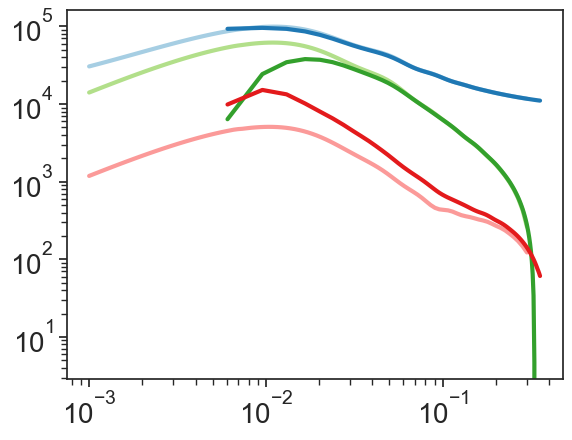

In [5]:
# Finally let's check the differences
plt.loglog(k, mps['ell0'])
plt.loglog(kout, mps_conv['ell0'])
plt.loglog(k, mps['ell2'])
plt.loglog(kout, mps_conv['ell2'])
plt.loglog(k, mps['ell4'])
plt.loglog(kout, mps_conv['ell4'])